<a href="https://colab.research.google.com/github/kundana12345/52.LASAnix-IPC-queue/blob/main/Copy_of_Unit8Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Your file on your github needs to be a a .ipynb file with the first four letters of one first name, the first four letters of one last name, and U6proj.

Ex1.

A student named Avy Aguacate Avocado Palta will submit a file named "Avy_AvocU8proj.ipynb", since she normally just goes by Avy, and, when pressed, reports Avocado as her last name. The " _ " after "Avy" serves as the fourth "letter" in her first name.

Ex2.

Army Armadillo will submit a file named "ArmyArmaU8proj.ipynb"

# Unit 8 Project: Writing a BARTical

**Task**:

Two parts:

1. Propose a data set that's compatible with a pymc_bart model. I must approve your submission before you move on to part 2.

2. Create, analyze, and present BART model, using pymc_bart within the colab environment, on a data set of your choice, with the following conditions:
  - your final model must have more than 2 predictors. The intercept term doesn't count as a predictor here (even though technically it is)
  - You must argue why your variable selection is justified. You may use either a theoretical or numerical argument. Additionally, you must comment on any potential interactions between your predictor variables.



Guidlines:

- Your data or your model type must be different from any project you've previously done.

- You are allowed to copy and paste any code from the notes, including my answer key (AK), without any reference or citations. Same goes for the course textbook, BAP3.

- This is an individual project. It is fine if you model the same process as a peer, but your raw data **must** be substantially different. "Substantially different" means that I, your instructor, arbitrarily think your data sets are different enough.

- Do not look at other student's code/jupyter notebooks. Copying, or copying and pasting, other students code will result in a failing grade. Also, I will tell all the other teachers I know that you cheated.

- If you want to know what another student did, ask them--any verbal communication about a project is allowed and encouraged. If you want to see a graphic they made, ask them to sketch a picture of it for you by hand.

- Any handwritten communication is also allowed and encouraged, so long as all parties are in the same physical location together. Example: you may sketch out a piece of code while verbally explaining to someone what you did. Do NOT: hand write the code for your entire project, take a picture, and send it to everyone in the course.

- If you use someone's code from outside this course (like from the internet, an AI, or your parent), you must ask me if it is ok, and you must cite them in your work. I don't care all they did was to click your space bar one more time: you tell me, and you cite their contribution. You don't need to tell me about or cite verbal or handwritten communication though.

- You may use a more complicated model--like something from further along in the course--IF I give you permission.

- If you are unsure whether or not something is ok or allowed: ASK BEFORE YOU DO IT.

Faliure to adhere to these guidlines will result in a failing grade.

Tips:

- Try to pick something that you care about, have knowledge of, experience with, or that you find interesting/cool.

- Gather data *before* picking a model or likelihood.

-  Use your best idea now; maybe you can look at the context you used in the previous project, and gather different data from it.

- Choose a data set with lots of columns, and lots of potential interactions between variables. It'll be more fun, and will make model/variable selection more relevant.

- Comment heavily, and explain your steps and thought process with text blocks. This is not only requried, it'll also help you understand what you're doing and what you want to do.

- Its ok to pick a data set for which you don't qute understand the context--so long as you think the context is cool.


In [1]:
#i used gemini

In [2]:
import pandas as pd
from google.colab import drive

# 1. Mount Google Drive
# drive.mount('/content/drive') # Mounting is no longer needed as data is from URL

# Define the file path from the new URL
file_path = 'https://raw.githubusercontent.com/kundana12345/DataScience/refs/heads/main/data.csv'

# 2. Load the data, assuming no header initially
df = pd.read_csv(file_path, header=None, encoding='latin1') # Using latin1 encoding as it's common for older datasets or specific characters

# 3. Extract variable titles from row 1997 onwards in column one (index 0)
# Remember that pandas is 0-indexed, so row 1997 is index 1996
column_titles_series = df.iloc[1996:, 0]

# Define the cleaning function
def clean_title(title):
    if title == '-- state: US state (by number) - not counted as predictive above':
        return 'state'
    else:
        # Remove '--' prefix if present
        if title.startswith('-- '):
            title = title[3:]
        # Remove everything after ':' if present
        if ':' in title:
            title = title.split(':', 1)[0]
        return title.strip()

# Apply the cleaning function to the extracted titles
cleaned_titles = column_titles_series.apply(clean_title)

# Transpose these values to be the very first row (new column headers)
# Since we only extracted the relevant part, we can directly set these as new columns
df.columns = cleaned_titles.tolist()

# First, let's check the number of cleaned titles vs. number of columns in df.
num_cleaned_titles = len(cleaned_titles)
num_df_cols = df.shape[1]

if num_cleaned_titles == num_df_cols:
    df.columns = cleaned_titles.tolist()
    # Now, drop the rows that contained the title descriptions (from 1996 onwards)
    df = df.iloc[:1996].copy() # Keep rows from 0 to 1995
    print("DataFrame with new headers and rows from 0-1995:")
    print(df.head())
    print(df.info())
else:
    print(f"Warning: Number of cleaned titles ({num_cleaned_titles}) does not match the number of columns in the DataFrame ({num_df_cols}).")
    print("Headers have been set from the extracted values, but data alignment might be an issue.")
    # The previous logic was based on mounting Google Drive and potentially a local file.
    # With a direct URL, the DataFrame `df` *should* represent the actual data starting from row 0.
    # The extracted `cleaned_titles` are expected to be the headers for this data.
    # The instruction was to 'transpose all these values to the very first row', meaning these *are* the headers.
    # The data itself is expected to be `df.iloc[:1996]` (rows 0 to 1995) after setting columns.

    # If the number of columns in the DataFrame is greater than the number of cleaned titles, pad with default names or raise an error.
    # If less, truncate cleaned_titles.
    if num_cleaned_titles < num_df_cols:
        df.columns = cleaned_titles.tolist() + [f'unnamed_col_{i}' for i in range(num_cleaned_titles, num_df_cols)]
    else: # num_cleaned_titles > num_df_cols
        df.columns = cleaned_titles.tolist()[:num_df_cols]

    df = df.iloc[:1996].copy() # Still assume data is before row 1996
    print("DataFrame with potentially adjusted headers and rows from 0-1995:")
    print(df.head())
    print(df.info())

DataFrame with new headers and rows from 0-1995:
  state county community        communityname  fold  population  \
0   NaN    NaN       NaN                  NaN   NaN         NaN   
1     8      ?         ?         Lakewoodcity   1.0        0.19   
2    53      ?         ?          Tukwilacity   1.0        0.00   
3    24      ?         ?         Aberdeentown   1.0        0.00   
4    34      5     81440  Willingborotownship   1.0        0.04   

   householdsize  racepctblack  racePctWhite  racePctAsian  ...  LandArea  \
0            NaN           NaN           NaN           NaN  ...       NaN   
1           0.33          0.02          0.90          0.12  ...      0.12   
2           0.16          0.12          0.74          0.45  ...      0.02   
3           0.42          0.49          0.56          0.17  ...      0.01   
4           0.77          1.00          0.08          0.12  ...      0.02   

   PopDens  PctUsePubTrans  PolicCars  PolicOperBudg  LemasPctPolicOnPatr  \
0      N

In [3]:
df

,state,county,community,communityname,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,...,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop,ViolentCrimesPerPop
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,8,?,?,Lakewoodcity,1.0,0.19,0.33,0.02,0.90,0.12,...,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14,0.20
2,53,?,?,Tukwilacity,1.0,0.00,0.16,0.12,0.74,0.45,...,0.02,0.12,0.45,?,?,?,?,0.00,?,0.67
3,24,?,?,Aberdeentown,1.0,0.00,0.42,0.49,0.56,0.17,...,0.01,0.21,0.02,?,?,?,?,0.00,?,0.43
4,34,5,81440,Willingborotownship,1.0,0.04,0.77,1.00,0.08,0.12,...,0.02,0.39,0.28,?,?,?,?,0.00,?,0.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1991,6,?,?,Seasidecity,10.0,0.05,0.96,0.46,0.28,0.83,...,0.02,0.37,0.20,?,?,?,?,0.00,?,0.45
1992,9,9,80070,Waterburytown,10.0,0.16,0.37,0.25,0.69,0.04,...,0.08,0.32,0.18,0.08,0.06,0.78,0,0.91,0.28,0.23
1993,25,17,72600,Walthamcity,10.0,0.08,0.51,0.06,0.87,0.22,...,0.03,0.38,0.33,0.02,0.02,0.79,0,0.22,0.18,0.19
1994,6,?,?,Ontariocity,10.0,0.20,0.78,0.14,0.46,0.24,...,0.11,0.30,0.05,0.08,0.04,0.73,0.5,1.00,0.13,0.48


In [4]:
# Drop only the 'communityname' column
df_cleaned = df.drop(columns=['communityname'])
print("DataFrame after dropping 'communityname' column:")
print(df_cleaned.info())
display(df_cleaned.head())

DataFrame after dropping 'communityname' column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1996 entries, 0 to 1995
Columns: 127 entries, state to ViolentCrimesPerPop
dtypes: float64(101), object(26)
memory usage: 1.9+ MB
None


,state,county,community,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,...,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop,ViolentCrimesPerPop
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,8,?,?,1.0,0.19,0.33,0.02,0.90,0.12,0.17,...,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14,0.20
2,53,?,?,1.0,0.00,0.16,0.12,0.74,0.45,0.07,...,0.02,0.12,0.45,?,?,?,?,0.00,?,0.67
3,24,?,?,1.0,0.00,0.42,0.49,0.56,0.17,0.04,...,0.01,0.21,0.02,?,?,?,?,0.00,?,0.43
4,34,5,81440,1.0,0.04,0.77,1.00,0.08,0.12,0.10,...,0.02,0.39,0.28,?,?,?,?,0.00,?,0.12


In [5]:
df_cleaned = df_cleaned.iloc[1:].copy()
print("DataFrame after deleting the first row:")
print(df_cleaned.info())
display(df_cleaned.head())

DataFrame after deleting the first row:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1995 entries, 1 to 1995
Columns: 127 entries, state to ViolentCrimesPerPop
dtypes: float64(101), object(26)
memory usage: 1.9+ MB
None


,state,county,community,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,...,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop,ViolentCrimesPerPop
1,8,?,?,1.0,0.19,0.33,0.02,0.90,0.12,0.17,...,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14,0.20
2,53,?,?,1.0,0.00,0.16,0.12,0.74,0.45,0.07,...,0.02,0.12,0.45,?,?,?,?,0.00,?,0.67
3,24,?,?,1.0,0.00,0.42,0.49,0.56,0.17,0.04,...,0.01,0.21,0.02,?,?,?,?,0.00,?,0.43
4,34,5,81440,1.0,0.04,0.77,1.00,0.08,0.12,0.10,...,0.02,0.39,0.28,?,?,?,?,0.00,?,0.12
5,42,95,6096,1.0,0.01,0.55,0.02,0.95,0.09,0.05,...,0.04,0.09,0.02,?,?,?,?,0.00,?,0.03


In [6]:
print(f"Current shape of df_cleaned: {df_cleaned.shape}")
print("Last 5 rows of df_cleaned:")
display(df_cleaned.tail())

Current shape of df_cleaned: (1995, 127)
Last 5 rows of df_cleaned:


,state,county,community,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,...,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop,ViolentCrimesPerPop
1991,6,?,?,10.0,0.05,0.96,0.46,0.28,0.83,0.32,...,0.02,0.37,0.20,?,?,?,?,0.00,?,0.45
1992,9,9,80070,10.0,0.16,0.37,0.25,0.69,0.04,0.25,...,0.08,0.32,0.18,0.08,0.06,0.78,0,0.91,0.28,0.23
1993,25,17,72600,10.0,0.08,0.51,0.06,0.87,0.22,0.10,...,0.03,0.38,0.33,0.02,0.02,0.79,0,0.22,0.18,0.19
1994,6,?,?,10.0,0.20,0.78,0.14,0.46,0.24,0.77,...,0.11,0.30,0.05,0.08,0.04,0.73,0.5,1.00,0.13,0.48
1995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df_cleaned

,state,county,community,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,...,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop,ViolentCrimesPerPop
1,8,?,?,1.0,0.19,0.33,0.02,0.90,0.12,0.17,...,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14,0.20
2,53,?,?,1.0,0.00,0.16,0.12,0.74,0.45,0.07,...,0.02,0.12,0.45,?,?,?,?,0.00,?,0.67
3,24,?,?,1.0,0.00,0.42,0.49,0.56,0.17,0.04,...,0.01,0.21,0.02,?,?,?,?,0.00,?,0.43
4,34,5,81440,1.0,0.04,0.77,1.00,0.08,0.12,0.10,...,0.02,0.39,0.28,?,?,?,?,0.00,?,0.12
5,42,95,6096,1.0,0.01,0.55,0.02,0.95,0.09,0.05,...,0.04,0.09,0.02,?,?,?,?,0.00,?,0.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1991,6,?,?,10.0,0.05,0.96,0.46,0.28,0.83,0.32,...,0.02,0.37,0.20,?,?,?,?,0.00,?,0.45
1992,9,9,80070,10.0,0.16,0.37,0.25,0.69,0.04,0.25,...,0.08,0.32,0.18,0.08,0.06,0.78,0,0.91,0.28,0.23
1993,25,17,72600,10.0,0.08,0.51,0.06,0.87,0.22,0.10,...,0.03,0.38,0.33,0.02,0.02,0.79,0,0.22,0.18,0.19
1994,6,?,?,10.0,0.20,0.78,0.14,0.46,0.24,0.77,...,0.11,0.30,0.05,0.08,0.04,0.73,0.5,1.00,0.13,0.48


In [8]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns
import graphviz as gv

In [9]:
!pip install pymc-bart
import pymc_bart as pmb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.9/179.9 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 10.8 MB/s eta 0:00:00


In [10]:
from sklearn import tree

In [11]:
#X is our predictor variable, upper beak measurment
X = df_cleaned["PopDens"].to_numpy()
#Y is the predicted variable, total beak weight
Y = df_cleaned["ViolentCrimesPerPop"].to_numpy()

In [12]:
dtree = tree.DecisionTreeRegressor(max_depth=2)

# Combine X and Y into a DataFrame to easily drop rows with NaNs in either
df_temp = pd.DataFrame({'X': X, 'Y': Y})
df_temp_cleaned = df_temp.dropna()

X_cleaned = df_temp_cleaned['X'].to_numpy().reshape(-1, 1)
Y_cleaned = df_temp_cleaned['Y'].to_numpy()

# Fit the model with the cleaned and reshaped data
octtree = dtree.fit(X_cleaned, Y_cleaned)

# uses the fitted model to predict total weight for various
# unseen upper beak measurements
# This is analogous to a posterior predictive distribution. . .
# . . .if we only found the posterior predictive mean...
# ...kinda.

# Create X_test, ensuring it's also a 2D array
# The range of X_test should ideally be within the range of X_cleaned for meaningful predictions
min_popdens = X_cleaned.min()
max_popdens = X_cleaned.max()
X_test = np.arange(min_popdens, max_popdens, 0.01).reshape(-1, 1)
y_pred = octtree.predict(X_test)

NameError: name 'y' is not defined

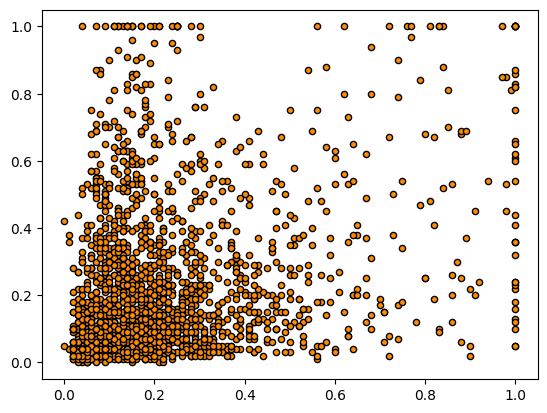

In [13]:
plt.figure()
plt.scatter(X, Y, s=20, edgecolor="black", c="darkorange", label="actual measurements")
plt.plot(X_test, y, color="cornflowerblue", linewidth=2)
plt.xlabel("upBeak")
plt.ylabel("totWt")
plt.title("Decision Tree Regression")
plt.legend()
plt.show()

In [ ]:
sns.pairplot(df_cleaned)

In [ ]:

with pm.Model() as model_octps:
    s = pm.HalfNormal('s',1000)
    μ_ = pmb.BART("μ_", X, np.log(Y), m=50)
    μ = pm.Deterministic("μ",pm.math.exp(μ_))
    y = pm.Gamma("y", mu=μ, sigma=s,  observed=Y)
    idata_octps = pm.sample(compute_convergence_checks=False)

In [ ]:
az.plot_ppc(idata_octps, num_pp_samples=100, colors=["C1", "C0", "C1"])

In [ ]:
posterior_mean = idata_octps.posterior["μ"]

μ_hdi = az.hdi(ary=idata_octps, group="posterior", var_names=["μ"], hdi_prob=0.74)

pps = az.extract(
    idata_octps, group="posterior_predictive", var_names=["y"]
).T